In [137]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('survey_results_public.csv', low_memory=False)


In [138]:
print(df.columns.to_list())

['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersona

In [139]:
print([col for col in df.columns if 'comp' in col.lower()])
print([col for col in df.columns if 'lang' in col.lower()])
print([col for col in df.columns if 'year' in col.lower()])
print([col for col in df.columns if 'remote' in col.lower()])

['CompTotal', 'AIComplex', 'ConvertedCompYearly']
['LanguageChoice', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'LanguagesHaveEntry', 'LanguagesWantEntry']
['YearsCode', 'ConvertedCompYearly']
['RemoteWork']


In [140]:
cols = ['ConvertedCompYearly', 'LanguageHaveWorkedWith', 'YearsCode', 'RemoteWork', 'EdLevel', 'Country', 'DevType', 'Age'] 
df = df[cols] 
print(df.shape) 
df.head()


(49191, 8)


,ConvertedCompYearly,LanguageHaveWorkedWith,YearsCode,RemoteWork,EdLevel,Country,DevType,Age
0,61256.0,Bash/Shell (all shells);Dart;SQL,14.0,Remote,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Ukraine,"Developer, mobile",25-34 years old
1,104413.0,Java,10.0,"Hybrid (some in-person, leans heavy to flexibi...","Associate degree (A.A., A.S., etc.)",Netherlands,"Developer, back-end",25-34 years old
2,53061.0,Dart;HTML/CSS;JavaScript;TypeScript,12.0,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Ukraine,"Developer, front-end",35-44 years old
3,36197.0,Java;Kotlin;SQL,5.0,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Ukraine,"Developer, back-end",35-44 years old
4,60000.0,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,22.0,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Ukraine,Engineering manager,35-44 years old


In [141]:
df.isnull().sum()

ConvertedCompYearly       25244
LanguageHaveWorkedWith    17520
YearsCode                  6149
RemoteWork                15411
EdLevel                    1042
Country                   13754
DevType                    5511
Age                           0
dtype: int64

In [142]:
conn = sqlite3.connect('survey.db')
df.to_sql('survey', conn, if_exists='replace', index=False)
print('Veri SQLite a yuklendi!')


Veri SQLite a yuklendi!


In [143]:
query = """
SELECT Country, COUNT(*) as count
FROM survey
WHERE Country IS NOT NULL
GROUP BY Country
ORDER BY count DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
result

,Country,count
0,United States of America,7233
1,Germany,3025
2,India,2547
3,United Kingdom of Great Britain and Northern I...,2042
4,France,1409
5,Canada,1305
6,Ukraine,964
7,Poland,888
8,Netherlands,867
9,Italy,835


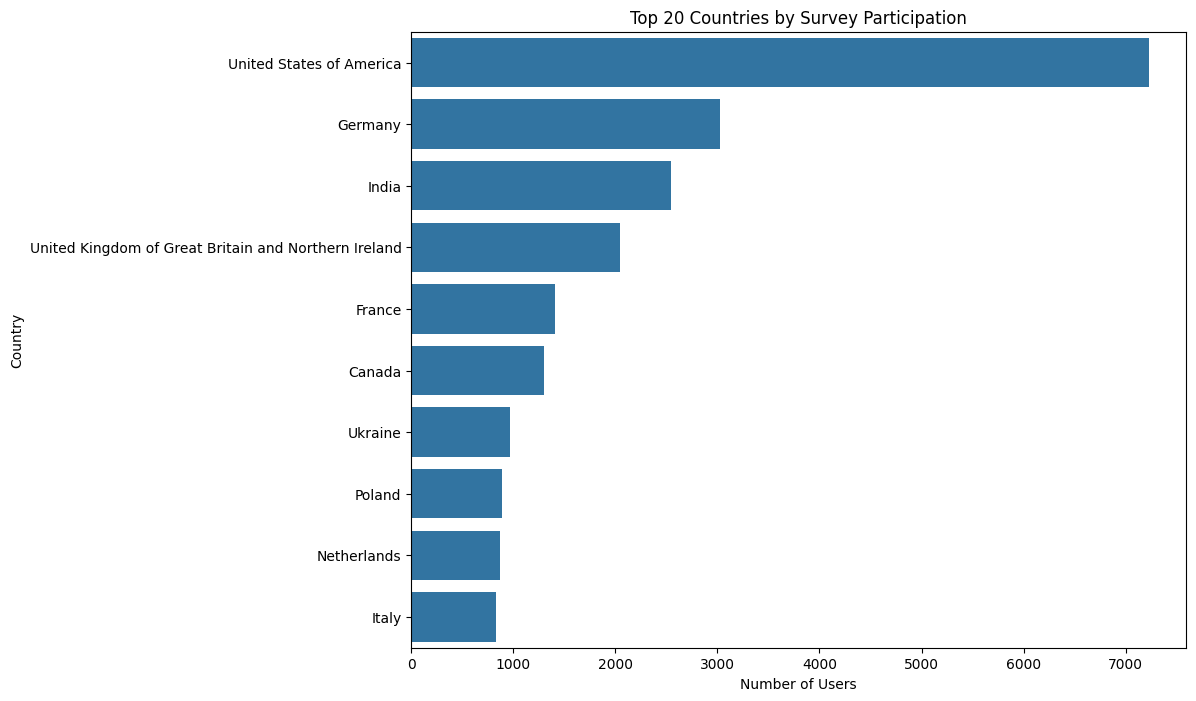

In [144]:
plt.figure(figsize=(10, 8))
sns.barplot(x=result['count'], y=result['Country'])
plt.title('Top 20 Countries by Survey Participation')
plt.xlabel('Number of Users')
plt.ylabel('Country')
plt.show()

In [145]:
languages = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
print(languages.head(10))
print(languages.value_counts().head(20))

0    Bash/Shell (all shells)
0                       Dart
0                        SQL
1                       Java
2                       Dart
2                   HTML/CSS
2                 JavaScript
2                 TypeScript
3                       Java
3                     Kotlin
Name: LanguageHaveWorkedWith, dtype: object
LanguageHaveWorkedWith
JavaScript                 21005
HTML/CSS                   19698
SQL                        18633
Python                     18410
Bash/Shell (all shells)    15503
TypeScript                 13859
Java                        9358
C#                          8852
C++                         7485
PowerShell                  7371
C                           6987
PHP                         5994
Go                          5219
Rust                        4724
Kotlin                      3420
Lua                         2910
Assembly                    2246
Ruby                        2046
Dart                        1885
Swift           

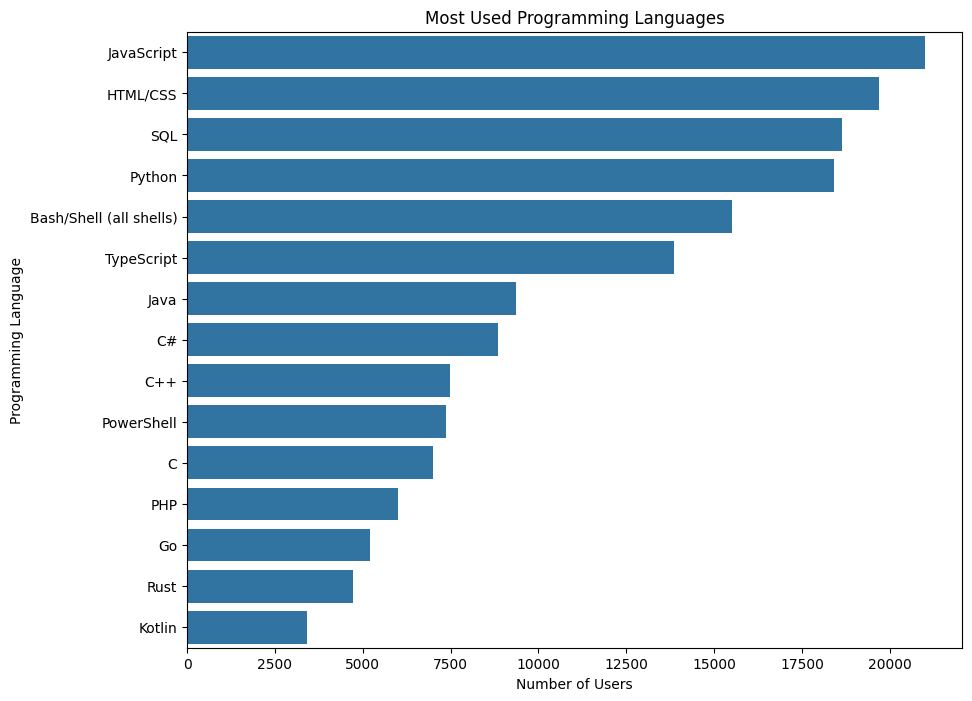

In [146]:
lang_counts = languages.value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=lang_counts.values, y=lang_counts.index)
plt.title('Most Used Programming Languages')
plt.xlabel('Number of Users')
plt.ylabel('Programming Language')
plt.show()

In [147]:
query = """
SELECT YearsCode, ROUND(AVG(ConvertedCompYearly), 2) as avg_salary
FROM survey
WHERE ConvertedCompYearly IS NOT NULL
AND YearsCode IS NOT NULL
AND ConvertedCompYearly < 300000
AND CAST(YearsCode AS FLOAT) <= 40
GROUP BY YearsCode
ORDER BY CAST(YearsCode AS FLOAT)
"""

salary_exp = pd.read_sql_query(query, conn)
salary_exp.head(10)

,YearsCode,avg_salary
0,1.0,24626.99
1,2.0,26037.16
2,3.0,25876.53
3,4.0,30412.30
4,5.0,39501.93
5,6.0,44029.76
6,7.0,50441.54
7,8.0,54321.49
8,9.0,64092.27
9,10.0,67900.97


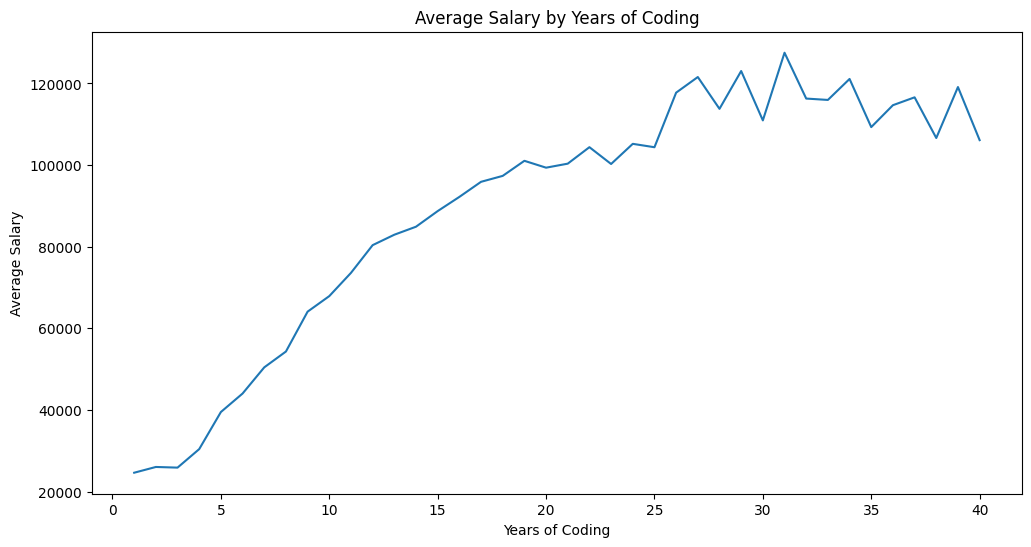

In [148]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearsCode', y='avg_salary', data=salary_exp)
plt.title('Average Salary by Years of Coding')
plt.xlabel('Years of Coding')
plt.ylabel('Average Salary')
plt.show()

In [149]:
query = """
SELECT RemoteWork, COUNT(*) as count
FROM survey
WHERE RemoteWork IS NOT NULL
GROUP BY RemoteWork
ORDER BY count DESC
LIMIT 10
"""

workstatus = pd.read_sql_query(query, conn)
workstatus

,RemoteWork,count
0,Remote,10931
1,"Hybrid (some remote, leans heavy to in-person)",6732
2,In-person,6042
3,"Hybrid (some in-person, leans heavy to flexibi...",5831
4,"Your choice (very flexible, you can come in wh...",4244


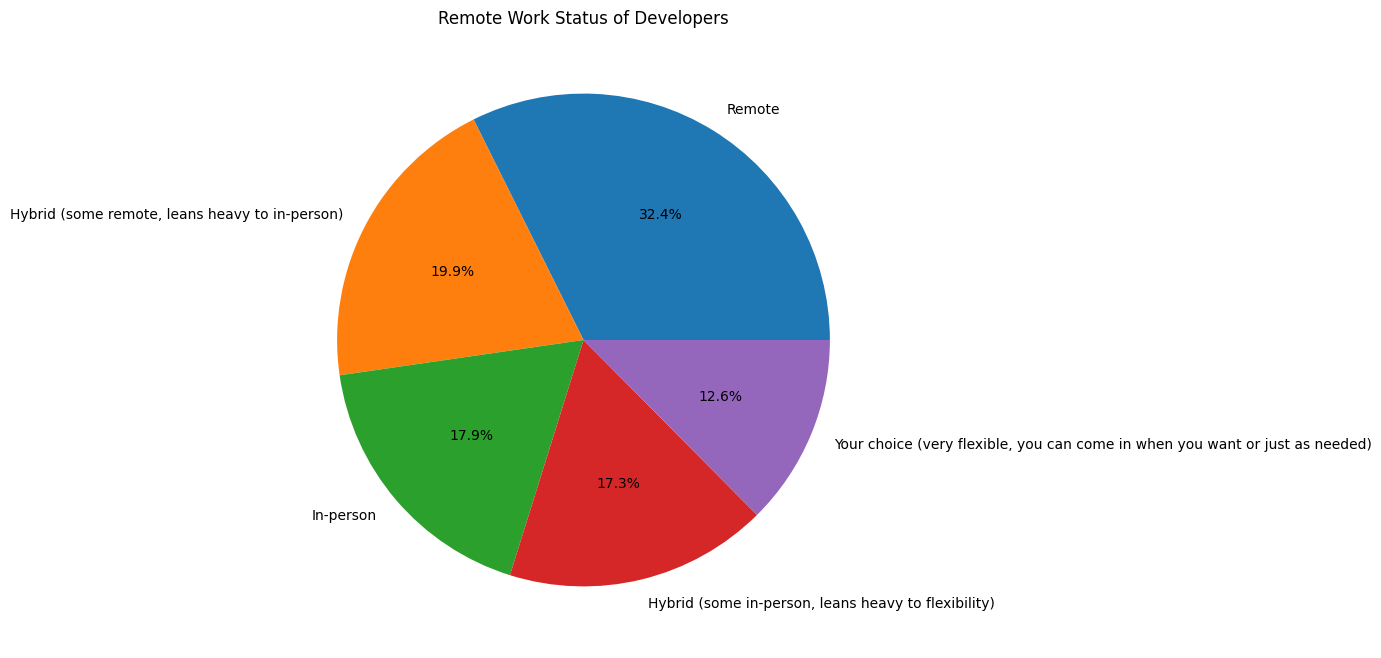

In [150]:
plt.figure(figsize=(10, 8))
plt.pie(workstatus['count'], labels=workstatus['RemoteWork'], autopct='%1.1f%%')
plt.title('Remote Work Status of Developers')
plt.show()

In [151]:
query = """
SELECT EdLevel, ROUND(AVG(ConvertedCompYearly), 2) AS avg_salary
FROM survey
WHERE EdLevel IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
GROUP BY EdLevel
ORDER BY avg_salary DESC
LIMIT 10
"""
edulevel = pd.read_sql_query(query, conn)
edulevel

,EdLevel,avg_salary
0,"Associate degree (A.A., A.S., etc.)",168992.08
1,Primary/elementary school,137027.83
2,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",128159.64
3,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",105050.79
4,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",98200.01
5,Other (please specify):,89789.79
6,Some college/university study without earning ...,87694.59
7,"Secondary school (e.g. American high school, G...",71214.10


In [152]:
query = """
SELECT EdLevel, COUNT(*) AS count
FROM survey
WHERE EdLevel IS NOT NULL
GROUP BY EdLevel
ORDER BY count DESC
LIMIT 10
"""
edulevel = pd.read_sql_query(query, conn)
edulevel

,EdLevel,count
0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",20278
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",12589
2,Some college/university study without earning ...,6182
3,"Secondary school (e.g. American high school, G...",3631
4,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",2624
5,"Associate degree (A.A., A.S., etc.)",1562
6,Other (please specify):,701
7,Primary/elementary school,582


In [153]:
query = """
SELECT EdLevel, ROUND(AVG(ConvertedCompYearly), 2) AS avg_salary, COUNT(*) as count
FROM survey
WHERE EdLevel IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
AND ConvertedCompYearly < 300000
GROUP BY EdLevel
HAVING count > 500
ORDER BY avg_salary DESC
"""
edulevel = pd.read_sql_query(query, conn)
edulevel

,EdLevel,avg_salary,count
0,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",95360.86,1299
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",86949.04,6728
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",84272.06,10143
3,"Associate degree (A.A., A.S., etc.)",78424.90,785
4,Some college/university study without earning ...,76417.95,2802
5,"Secondary school (e.g. American high school, G...",60363.72,1195


In [157]:
query = """
SELECT EdLevel, ROUND(AVG(ConvertedCompYearly), 2) AS avg_salary, COUNT(*) as count
FROM survey
WHERE EdLevel IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
AND ConvertedCompYearly < 300000
GROUP BY EdLevel
HAVING count > 500
ORDER BY avg_salary DESC
"""
edulevel = pd.read_sql_query(query, conn)
print(edulevel['EdLevel'].tolist())

['Professional degree (JD, MD, Ph.D, Ed.D, etc.)', 'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)', 'Bachelor’s degree (B.A., B.S., B.Eng., etc.)', 'Associate degree (A.A., A.S., etc.)', 'Some college/university study without earning a degree', 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)']


In [158]:
edu_order = [
    edulevel['EdLevel'].tolist()[5],  # Secondary school
    edulevel['EdLevel'].tolist()[4],  # Some college
    edulevel['EdLevel'].tolist()[3],  # Associate
    edulevel['EdLevel'].tolist()[2],  # Bachelor's
    edulevel['EdLevel'].tolist()[1],  # Master's
    edulevel['EdLevel'].tolist()[0],  # Professional
]

edulevel['EdLevel'] = pd.Categorical(edulevel['EdLevel'], categories=edu_order, ordered=True)
edulevel = edulevel.sort_values('EdLevel')
edulevel

,EdLevel,avg_salary,count
5,"Secondary school (e.g. American high school, G...",60363.72,1195
4,Some college/university study without earning ...,76417.95,2802
3,"Associate degree (A.A., A.S., etc.)",78424.90,785
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",84272.06,10143
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",86949.04,6728
0,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",95360.86,1299


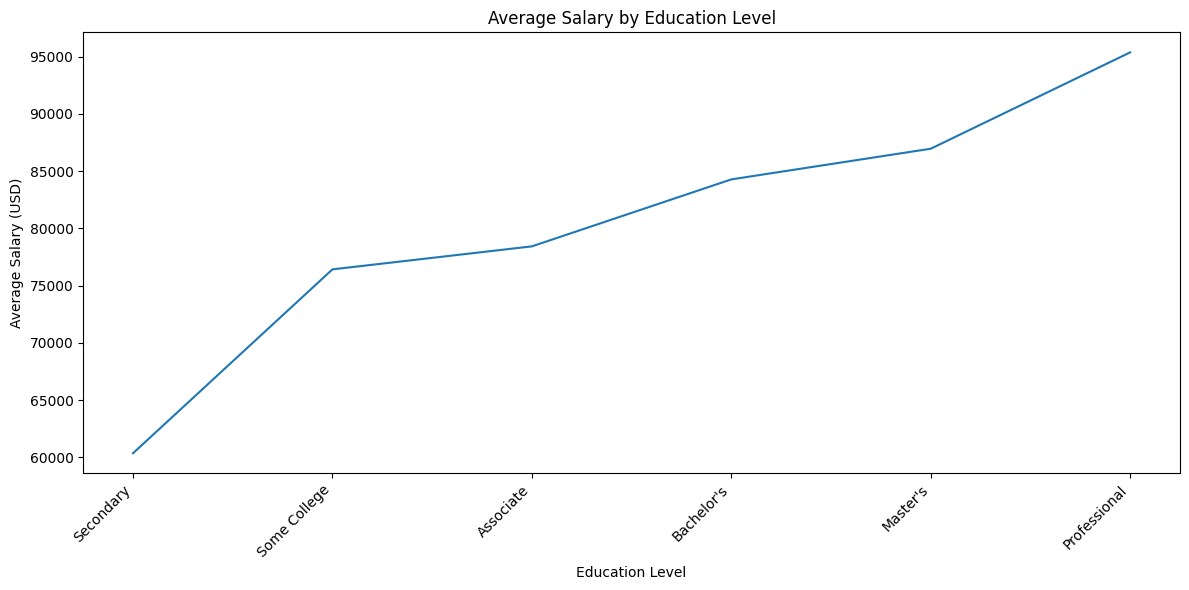

In [164]:
edulevel['EdLevel_short'] = [
    'Secondary',
    'Some College',
    'Associate',
    "Bachelor's",
    "Master's",
    'Professional']

plt.figure(figsize=(12, 6))
sns.lineplot(x=edulevel['EdLevel_short'], y=edulevel['avg_salary'])
plt.title('Average Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In this project, I analyzed the Stack Overflow Developer Survey 2025
to understand trends in the developer community.

Key findings:
1. The majority of respondents are from the US, Germany, and India. 
   Results may be biased as the survey is conducted in English.
2. The most popular languages are JavaScript, HTML/CSS, SQL, and Python.
3. Salary increases with experience — especially after the first 3 years 
   where growth is slow, it then increases dramatically.
4. Most developers work remotely — only a small portion works fully in-office.
5. Higher education levels correlate with higher salaries, though results 
   for smaller groups should be interpreted carefully.

Next steps: A deeper analysis could explore salary differences by country, 
or investigate which developer types earn the most.